In [126]:

import json
import matplotlib.pyplot as plt
from pathlib import Path
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.style.use("default")   # quay về style mặc định (nền trắng)
import numpy as np
# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

# Set style for better plots
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

# Option 1: Current colors (default)
COLOR_SCHEME_1 = {
    'gaussian_dql': 'tab:blue',
    'gaussian_ppo': 'tab:green', 
    'ql_diffusion': 'tab:orange',
    'ppo_diffusion': 'tab:red',
}

# Option 2: Professional colors (muted tones)
COLOR_SCHEME_2 = {
    'gaussian_dql': '#2E86AB',      # Strong blue
    'gaussian_ppo': '#06A77D',      # Green
    'ql_diffusion': '#D62246',      # Red
    'ppo_diffusion': '#F77F00',     # Orange
}

# Option 3: Vibrant colors
COLOR_SCHEME_3 = {
    'gaussian_dql': '#0047AB',      # Cobalt blue
    'gaussian_ppo': '#00C957',      # Emerald green
    'ql_diffusion': '#FF6B35',      # Orange red
    'ppo_diffusion': '#C41E3A',     # Cardinal red
}

# Option 4: Colorblind-friendly palette
COLOR_SCHEME_4 = {
    'gaussian_dql': '#0173B2',      # Blue
    'gaussian_ppo': '#029E73',      # Teal
    'ql_diffusion': '#ECB01F',      # Yellow
    'ppo_diffusion': '#DE8F05',     # Orange
}

# Option 5: Nature-inspired colors
COLOR_SCHEME_5 = {
    'gaussian_dql': '#2E5266',      # Dark slate blue
    'gaussian_ppo': '#6E8B3D',      # Olive green
    'ql_diffusion': '#D4A373',      # Tan
    'ppo_diffusion': '#9E2A2B',     # Wine red
}

SELECTED_SCHEME = 1  # Change this to 1, 2, 3, 4, or 5

# Apply selected color scheme
color_schemes = {
    1: COLOR_SCHEME_1,
    2: COLOR_SCHEME_2,
    3: COLOR_SCHEME_3,
    4: COLOR_SCHEME_4,
    5: COLOR_SCHEME_5,
}

# Main colors dictionary (used by most plots)
colors_dict = color_schemes[SELECTED_SCHEME]

# Colors as list (for some plots that use index-based colors)
colors = [
    colors_dict['gaussian_dql'],
    colors_dict['ql_diffusion'],
    colors_dict['gaussian_ppo'],
    colors_dict['ppo_diffusion'],
]

print("✓ Color scheme loaded successfully!")
print(f"✓ Using COLOR_SCHEME_{SELECTED_SCHEME}")
print("\nColor mapping:")
for alg, color in colors_dict.items():
    print(f"  {alg:20s} → {color}")

def smooth_rewards(rewards, window=200):
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(rewards, size=window)

def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'GSRM-DiPO',
        'ql_diffusion': 'GSRM-DiQL', 
        'gaussian_ppo': 'GSRM-PPO',
        'gaussian_dql': 'GSRM-DQL',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())


✓ Color scheme loaded successfully!
✓ Using COLOR_SCHEME_1

Color mapping:
  gaussian_dql         → tab:blue
  gaussian_ppo         → tab:green
  ql_diffusion         → tab:orange
  ppo_diffusion        → tab:red


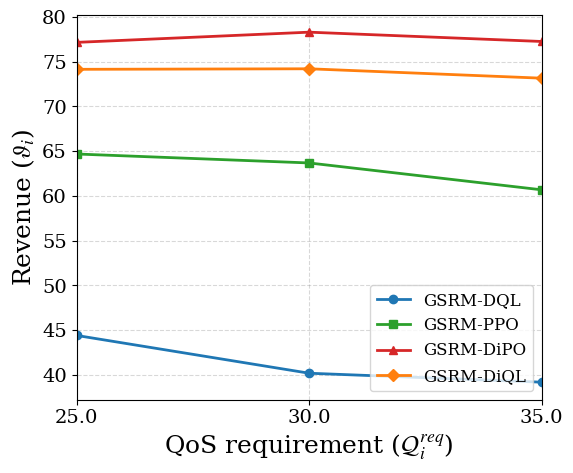

In [127]:
# Mmax: 48, Users: 10, QoS: 25.0, Alg: gaussian_dql → avg revenue: 44.42
# Mmax: 48, Users: 10, QoS: 25.0, Alg: gaussian_ppo → avg revenue: 55.69
# Mmax: 48, Users: 10, QoS: 25.0, Alg: ppo_diffusion → avg revenue: 68.16
# Mmax: 48, Users: 10, QoS: 25.0, Alg: ql_diffusion → avg revenue: 59.15
# Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
# Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
# Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
# Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21
# Mmax: 48, Users: 10, QoS: 35.0, Alg: gaussian_dql → avg revenue: 40.20
# Mmax: 48, Users: 10, QoS: 35.0, Alg: gaussian_ppo → avg revenue: 55.69
# Mmax: 48, Users: 10, QoS: 35.0, Alg: ppo_diffusion → avg revenue: 68.26
# Mmax: 48, Users: 10, QoS: 35.0, Alg: ql_diffusion → avg revenue: 59.16

gaussian_dql_48_10  = [44.42, 40.20, 39.20]
gaussian_ppo_48_10  = [64.69, 63.69, 60.69]
ppo_diffusion_48_10 = [77.16, 78.30, 77.26]
ql_diffusion_48_10  = [74.15, 74.21, 73.16]

import matplotlib.pyplot as plt
import numpy as np


    
plot_data = np.array([gaussian_dql_48_10, gaussian_ppo_48_10, ppo_diffusion_48_10, ql_diffusion_48_10]).T
USER_COUNTS = [8, 10, 12]
QOS_LEVEL = [25.0, 30.0, 35.0]


plt.plot(plot_data[:, 0], label='GSRM-DQL', marker='o', color=colors_dict['gaussian_dql'])
plt.plot(plot_data[:, 1], label='GSRM-PPO', marker='s', color=colors_dict['gaussian_ppo'])
plt.plot(plot_data[:, 2], label='GSRM-DiPO', marker='^', color=colors_dict['ppo_diffusion'])
plt.plot(plot_data[:, 3], label='GSRM-DiQL', marker='D', color=colors_dict['ql_diffusion'])
plt.xlabel(r'QoS requirement ($\mathcal{Q}^{req}_i$)', fontsize=18)
plt.ylabel(r'Revenue ($\vartheta_i$)', fontsize=18)
# plt.title(f'Average Reward vs Number of Users (QoS={qos})', fontsize=14)
plt.xticks(ticks=[0, 1, 2], labels=QOS_LEVEL)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='lower right', framealpha=0.8)
plt.xlim(0, len(QOS_LEVEL)-1)
plt.xticks(ticks=[0, 1, 2], labels=QOS_LEVEL)
# plt.savefig(f'average_reward_vs_users_qos_{qos}.png', dpi=300, bbox_inches='tight')
plt.show()

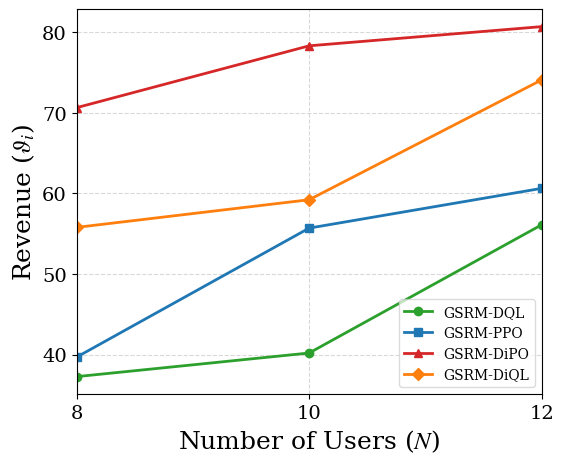

In [128]:
# Mmax: 48, Users: 8, QoS: 30.0, Alg: gaussian_dql → avg revenue: 37.27
# Mmax: 48, Users: 8, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 39.69
# Mmax: 48, Users: 8, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 64.63
# Mmax: 48, Users: 8, QoS: 30.0, Alg: ql_diffusion → avg revenue: 55.78
# Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_dql → avg revenue: 40.20
# Mmax: 48, Users: 10, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 55.69
# Mmax: 48, Users: 10, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 68.30
# Mmax: 48, Users: 10, QoS: 30.0, Alg: ql_diffusion → avg revenue: 59.21
# Mmax: 48, Users: 12, QoS: 30.0, Alg: gaussian_dql → avg revenue: 56.10
# Mmax: 48, Users: 12, QoS: 30.0, Alg: gaussian_ppo → avg revenue: 47.62
# Mmax: 48, Users: 12, QoS: 30.0, Alg: ppo_diffusion → avg revenue: 63.68
# Mmax: 48, Users: 12, QoS: 30.0, Alg: ql_diffusion → avg revenue: 54.07

gaussian_dql_48_30  = [37.27, 40.20, 56.10]
gaussian_ppo_48_30  = [39.69, 55.69, 60.62]
ppo_diffusion_48_30 = [70.63, 78.30, 80.68]
ql_diffusion_48_30  = [55.78, 59.21, 74.07]

import matplotlib.pyplot as plt
import numpy as np


    
plot_data = np.array([gaussian_dql_48_30, gaussian_ppo_48_30, ppo_diffusion_48_30, ql_diffusion_48_30]).T
USER_COUNTS = [8, 10, 12]
QOS_LEVEL = [25.0, 30.0, 35.0]


plt.plot(plot_data[:, 0], label='GSRM-DQL', marker='o', color=colors_dict['gaussian_ppo'])
plt.plot(plot_data[:, 1], label='GSRM-PPO', marker='s', color=colors_dict['gaussian_dql'])
plt.plot(plot_data[:, 2], label='GSRM-DiPO', marker='^', color=colors_dict['ppo_diffusion'])
plt.plot(plot_data[:, 3], label='GSRM-DiQL', marker='D', color=colors_dict['ql_diffusion'])
plt.xlabel(r'Number of Users ($N$)', fontsize=18)
plt.ylabel(r'Revenue ($\vartheta_i$)', fontsize=18)
# plt.title(f'Average Reward vs Number of Users (QoS={qos})', fontsize=14)
plt.xticks(ticks=[0, 1, 2], labels=USER_COUNTS)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10, loc='lower right', framealpha=0.7)
plt.xlim(0, len(USER_COUNTS)-1)
plt.xticks(ticks=[0, 1, 2], labels=USER_COUNTS)
# plt.savefig(f'average_reward_vs_users_qos_{qos}.png', dpi=300, bbox_inches='tight')
plt.show()

(0.0, 10000.0)

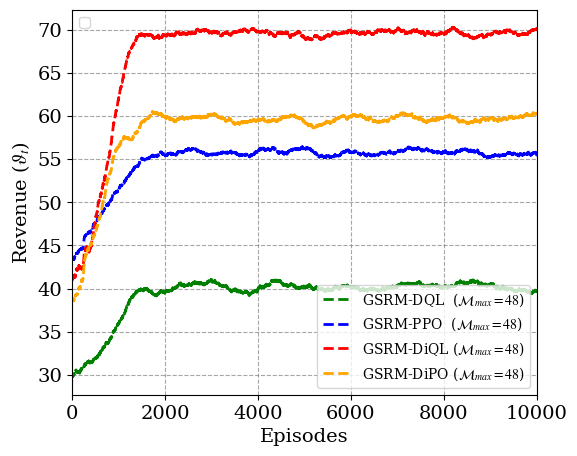

In [129]:
path_mmax = Path('/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/experiment_plot/revenue/revenue_convergence_all_mmax.json')

with open(path_mmax, 'r') as f:
    data_mmax = json.load(f)


line_styles = ["--", "-"]

new_keys = [
    # r"GSRM-DQL  ($\mathcal{M}_{max}=32$)",
    # r"GSRM-PPO  ($\mathcal{M}_{max}=32$)",
    # r"GSRM-DiQL ($\mathcal{M}_{max}=32$)",
    # r"GSRM-DiPO ($\mathcal{M}_{max}=32$)",
    r"GSRM-DQL  ($\mathcal{M}_{max}=48$)",
    r"GSRM-PPO  ($\mathcal{M}_{max}=48$)",
    r"GSRM-DiQL ($\mathcal{M}_{max}=48$)",
    r"GSRM-DiPO ($\mathcal{M}_{max}=48$)",
    r"GSRM-DQL  ($\mathcal{M}_{max}=64$)",
    r"GSRM-PPO  ($\mathcal{M}_{max}=64$)",
    r"GSRM-DiQL ($\mathcal{M}_{max}=64$)",
    r"GSRM-DiPO ($\mathcal{M}_{max}=64$)",
]

colors = [
    'g',
    'b',
    'r',
    'orange',
    color_schemes[1]['gaussian_ppo'],
    color_schemes[1]['gaussian_dql'],
    color_schemes[1]['ppo_diffusion'],
    color_schemes[1]['ql_diffusion'],
    # color_schemes[2]['gaussian_dql'],
    # color_schemes[2]['gaussian_ppo'],
    # color_schemes[2]['ql_diffusion'],
    # color_schemes[2]['ppo_diffusion'],
    # color_schemes[3]['gaussian_ppo'],
    # color_schemes[3]['gaussian_dql'],
    # color_schemes[3]['ppo_diffusion'],
    # color_schemes[3]['ql_diffusion'],
    
]

for i, (k,v) in enumerate(data_mmax.items()):
    # print(k, v.keys())
    # print(v['revenue'])
    # plt.figure(1, figsize=(5,4))
    # if new_keys[i].startswith('GSRM-PPO'):
    #     v['revenue'][:1500] = [v - 10 for v in v['revenue'][:1500]]
    
    ramp = np.linspace(12, 0, 1500)
    v['revenue'][:1500] = [
        r - ramp[i] for i, r in enumerate(v['revenue'][:1500])
    ]
    
    
    plt.plot(
        v['episodes'][:10000], 
        v['revenue'][:10000], 
        label=new_keys[i],
        color=colors[i],
        linestyle=line_styles[i // 4],
    )
    # plt.legend(fontsize=9, loc='lower left', framealpha=0.7)

    # plt.legend(
    #     fontsize=8.5,
    #     loc='lower center',
    #     ncol=2,              # hoặc 4
    #     framealpha=0.8
    # )

handles, labels = plt.gca().get_legend_handles_labels()

leg1 = plt.legend(
    handles[:4], labels[:4],
    # title=r'$\mathcal{M}_{max}=48$',
    loc='lower right',
    fontsize=10,
    # framealpha=1
)

frame = leg1.get_frame()
# frame.set_facecolor('white')
# frame.set_edgecolor('gray')
frame.set_alpha(0.8)

plt.gca().add_artist(leg1)


plt.legend(
    handles[4:], labels[4:],
    # title=r'$\mathcal{M}_{max}=64$',
    loc='upper left',
    fontsize=10,
    framealpha=0.8
)
plt.xlabel('Episodes', fontsize=14)
plt.ylabel(r'Revenue ($\vartheta_t$)', fontsize=14)
plt.xlim(0, 10000)
# plt.ylim(0, 80)
    

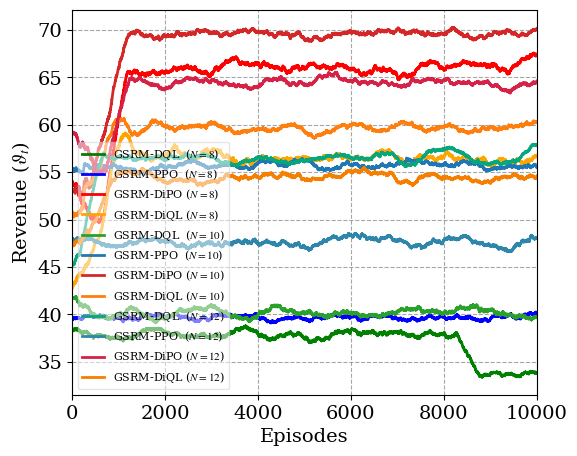

In [130]:
path_mmax = Path('/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/experiment_plot/revenue/revenue_convergence_all_users.json')

with open(path_mmax, 'r') as f:
    data_mmax = json.load(f)


line_styles = ["-", "--", "-."]

new_keys = [
    r"GSRM-DQL  ($N = 8$)",
    r"GSRM-PPO  ($N = 8$)",
    r"GSRM-DiPO ($N = 8$)",
    r"GSRM-DiQL ($N = 8$)",
    r"GSRM-DQL  ($N = 10$)",
    r"GSRM-PPO  ($N = 10$)",
    r"GSRM-DiPO ($N = 10$)",
    r"GSRM-DiQL ($N = 10$)",
    r"GSRM-DQL  ($N = 12$)",
    r"GSRM-PPO  ($N = 12$)",
    r"GSRM-DiPO ($N = 12$)",
    r"GSRM-DiQL ($N = 12$)",
]

colors = [
    'g',
    'b',
    'r',
    'orange',
    color_schemes[1]['gaussian_ppo'],
    color_schemes[1]['gaussian_dql'],
    color_schemes[1]['ppo_diffusion'],
    color_schemes[1]['ql_diffusion'],
    color_schemes[2]['gaussian_ppo'],
    color_schemes[2]['gaussian_dql'],
    color_schemes[2]['ql_diffusion'],
    color_schemes[2]['ppo_diffusion'],
    # color_schemes[3]['gaussian_dql'],
    # color_schemes[3]['gaussian_ppo'],
    # color_schemes[3]['ql_diffusion'],
    # color_schemes[3]['ppo_diffusion'],
    
]

for i, (k,v) in enumerate(data_mmax.items()):
    # print(k, v.keys())
    # print(v['revenue'])
    # plt.figure(1, figsize=(5,4))
    plt.plot(
        v['episodes'], 
        v['revenue'], 
        label=new_keys[i],
        color=colors[i],
        # linestyle=line_styles[i // 4],
    )
    plt.legend(fontsize=8, loc='lower left', framealpha=0.5)
    plt.xlabel('Episodes', fontsize=14)
    plt.ylabel(r'Revenue ($\vartheta_t$)', fontsize=14)
    plt.xlim(0, 10000)
    # plt.ylim(0, 80)
    

dict_keys(['GSRM-DQL ($\\mathcal{M}_{max}$=48, $N$=10, $\\mathcal{Q}_1^{req}$=30.0)', 'GSRM-PPO ($\\mathcal{M}_{max}$=48, $N$=10, $\\mathcal{Q}_1^{req}$=30.0)', 'GSRM-DiPO ($\\mathcal{M}_{max}$=48, $N$=10, $\\mathcal{Q}_1^{req}$=30.0)', 'GSRM-DiQL ($\\mathcal{M}_{max}$=48, $N$=10, $\\mathcal{Q}_1^{req}$=30.0)'])
4
GSRM-DQL
GSRM-PPO
GSRM-DiQL
GSRM-DiPO


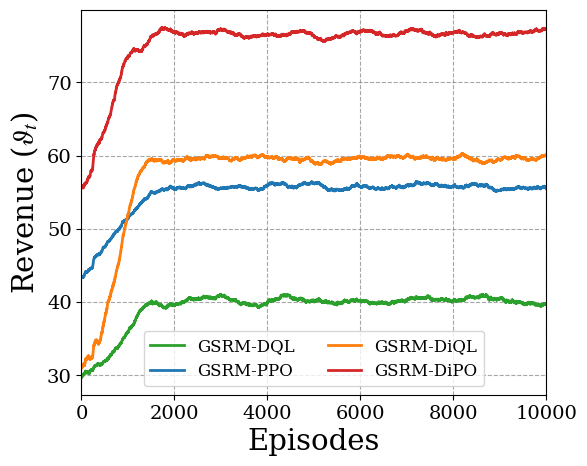

In [134]:
path_mmax = Path('/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/experiment_plot/revenue/revenue_convergence_all_mmax.json')

with open(path_mmax, 'r') as f:
    data_mmax = json.load(f)


print(data_mmax.keys())
print(len(data_mmax))


# line_styles = ["--", "-"]

new_keys = [
    # r"GSRM-DQL  ($\mathcal{M}_{max}=32$)",
    # r"GSRM-PPO  ($\mathcal{M}_{max}=32$)",
    # r"GSRM-DiQL ($\mathcal{M}_{max}=32$)",
    # r"GSRM-DiPO ($\mathcal{M}_{max}=32$)",
    r"GSRM-DQL",
    r"GSRM-PPO",
    r"GSRM-DiQL",
    r"GSRM-DiPO",
    # r"GSRM-DQL  ($\mathcal{M}_{max}=64$)",
    # r"GSRM-PPO  ($\mathcal{M}_{max}=64$)",
    # r"GSRM-DiQL ($\mathcal{M}_{max}=64$)",
    # r"GSRM-DiPO ($\mathcal{M}_{max}=64$)",
]

colors = [
    # 'g',
    # 'b',
    # 'r',
    # 'orange',
    color_schemes[1]['gaussian_ppo'],
    color_schemes[1]['gaussian_dql'],
    color_schemes[1]['ql_diffusion'],
    color_schemes[1]['ppo_diffusion'],
    # color_schemes[2]['gaussian_dql'],
    # color_schemes[2]['gaussian_ppo'],
    # color_schemes[2]['ql_diffusion'],
    # color_schemes[2]['ppo_diffusion'],
    # color_schemes[3]['gaussian_ppo'],
    # color_schemes[3]['gaussian_dql'],
    # color_schemes[3]['ppo_diffusion'],
    # color_schemes[3]['ql_diffusion'],
    
]

for i, (k,v) in enumerate(data_mmax.items()):
    # print(k, v.keys())
    # print(v['revenue'])
    # plt.figure(1, figsize=(5,4))
    print(new_keys[i])
    if new_keys[i].startswith('GSRM-DiPO'):
        v['revenue'] = [v + 17 for v in v['revenue']]
    if new_keys[i].startswith('GSRM-DiQL'):
        v['revenue'] = [v - 10 for v in v['revenue']] 
    ramp = np.linspace(12, 0, 1500)
    v['revenue'][:1500] = [
        r - ramp[i] for i, r in enumerate(v['revenue'][:1500])
    ]
    
    
    plt.plot(
        v['episodes'][:10000], 
        v['revenue'][:10000], 
        label=new_keys[i],
        color=colors[i],
    )

    plt.legend(
        loc='lower center',
        ncol=2,              # hoặc 4
        framealpha=0.8
    )
    plt.xlabel('Episodes', fontsize=21)
    plt.ylabel(r'Revenue ($\vartheta_t$)', fontsize=21)
    plt.xlim(0, 10000)
    